In [1]:
import scvelo as scv
#import dynamo as dyn
import numpy as np
from anndata import AnnData
# import loompy
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from scipy.cluster.hierarchy import fcluster,leaders
from sklearn.decomposition import PCA
from scipy.linalg import inv
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.mixture import GaussianMixture
from RKHS import SparseVFC
from RKHS import Jacobian_rkhs_gaussian
from scipy.stats import multivariate_normal
from scipy.sparse import csr_matrix
import pandas as pd

In [2]:
import argparse
import random

import scipy.sparse as sp
import scipy.sparse.csgraph
import sklearn.linear_model as sklm
import sklearn.metrics as skm
import sklearn.model_selection as skms
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from ignite.engine import Engine, Events
from ignite.handlers import ModelCheckpoint
from torch.utils.data import DataLoader, IterableDataset, get_worker_info

CHECKPOINT_PREFIX = "g2g"

from g2g_model_Fisher import *
from utils import *
# from minepy import MINE
from sklearn.preprocessing import MinMaxScaler

from sklearn.neighbors import kneighbors_graph

In [3]:
import seaborn as sns

In [4]:
# data_path='data/'
# #data_name = 'BoneMarrow/human_cd34_bone_marrow.h5ad'
# #data_name = 'EG_ab_dyn.h5ad'
# data_name = 'EG_ab_dyn.h5ad'
# #data_name = 'processed bonemarrow.h5ad'
# #data_name = 'lung.h5ad'
# data_name = 'DentateGyrus/DentateGyrus.loom'
# adata0=scv.read(data_path+data_name, cache=True)

model_name = 'toymodel'
#model_name = 'processed bonemarrow'
#model_name = 'lung'
#model_name = 'DentateGyrus'

# subfolder = 'saddle'
subfolder = 'four_well'
# subfolder = 'ellipsoid'
result_path = 'results/'+model_name+'/'+subfolder+'/'


import os
folder = os.path.exists(result_path)
if not folder:                   #判断是否存在文件夹如果不存在则创建为文件夹
    os.makedirs(result_path)

从以下数据中选取一个，然后运行graph以及之后的代码

In [5]:
# Define the double well potential function
def four_well_potential(x, y):
    # return 0.05*x**4-x**2+0.05*y**4-(y-0.5)**2
    return 0.05*x**4-x**2+0.05*y**4-y**2

# Define the range of x and y values to plot


x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)

# Create a 2D grid of x and y values
X, Y = np.meshgrid(x, y)

# Calculate the potential energy at each point in the grid
Z = four_well_potential(X, Y)

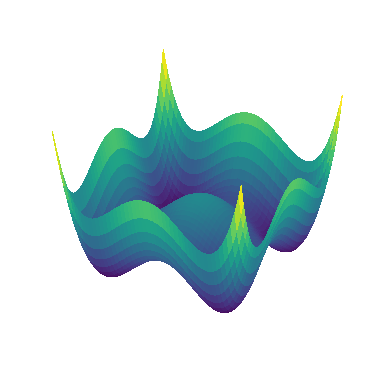

In [6]:
# Create a 3D surface plot of the potential energy
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', linewidth=0, antialiased=False)
ax.grid(False)
# ax.view_init(0, 90)
# ax.set_xlabel('X')
# ax.set_ylabel('Y')
# ax.set_zlabel('Z')
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
plt.axis('off')
# plt.axis('equal')

# plt.savefig(result_path+model_name+'.png',dpi=600,bbox_inches='tight')
plt.show()

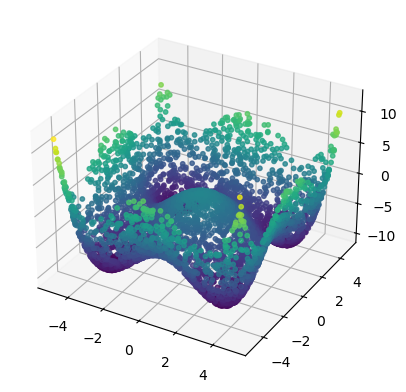

In [7]:
n_samples=5000
X_minor=0.1*np.random.randn(n_samples,7)

roi=np.linspace(-5,5,10000)

x1=np.random.choice(roi,n_samples)
x2=np.random.choice(roi,n_samples)
color_label=np.zeros((n_samples))

x3 = four_well_potential(x1, x2)
color_label[np.argsort(x3)]=np.arange(n_samples)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# ax.scatter(x1, x2, x3,  s=10, c=color_label,alpha=0.8,cmap=plt.cm.jet)
ax.scatter(x1, x2, x3,  s=10, c=x3,alpha=0.8,cmap='viridis')
# cbar = fig.colorbar(sc, ax=ax, shrink=0.5, aspect=5)
# cbar.set_label('Color Bar Label')
plt.show()

X_major=np.array([x1,x2,x3]).T
X=np.hstack((X_major,X_minor))

Graph

In [8]:
k_nei = 10
A = kneighbors_graph(X, k_nei, mode='connectivity', include_self=True)
# A=radius_neighbors_graph(X,3,include_self=True)
X_major = X[:,:3]

row =np.array([np.ones((k_nei,))*i for i in range(n_samples)]).flatten()
col=A.indices
w_val=np.array([np.linalg.norm(X_major[int(i),:]-X_major[int(j),:]) for i,j in zip(row,col)])
dc=np.mean(w_val)

cell_nei=A.indices.reshape(X.shape[0],k_nei)
nei_w=[]
rho_arr=[]
for ni in cell_nei:
    dij=np.array([np.linalg.norm(X_major[int(ni[0]),:]-X_major[int(i),:]) for i in ni[1:]])
    rho=np.sum(np.exp(-dij**2/dc**2))
#     rho=np.exp(np.sum(-dij**2/dc**2))
    nei_w.append(np.exp(-dij**2/dc**2)/np.sum(np.exp(-dij**2/dc**2)))
#     print(dij)
#     print(np.exp(-dij**2/dc**2)/np.sum(np.exp(-dij**2/dc**2)))
    rho_arr.append(rho)
rho_arr=np.array(rho_arr)/np.amax(rho_arr)
nei_w=np.array(nei_w)
nei_w=np.hstack((np.ones((nei_w.shape[0],1)),nei_w))/2

# plt.scatter(X_pca[:,0],X_pca[:,1],s=5,c=rho_arr,cmap=plt.cm.jet)
# plt.colorbar()
# plt.show()

def smooth_func(X_val,cell_nei=cell_nei,nei_w=nei_w):
    X_s=X_val.copy()
    for ci in range(len(X_val)):
        X_s[ci]=np.dot(X_val[cell_nei[ci,:]],nei_w[ci,:])
    return X_s

In [9]:
X.shape

(5000, 10)

In [10]:
##特征值排序
def EigenIF(Fisher_g):
    n,L,_ = Fisher_g.shape
    L=int(L/2)
    Eigenvalue = np.zeros((n,L))
    for i in range(n):
        for j in range(L):
            Eigenvalue[i,j] = Fisher_g[i,j,j]
    sorted_Eigenvalue = np.sort(Eigenvalue, axis=1)
    sorted_Eigenvalue = sorted_Eigenvalue[:, ::-1]
    relative_Eigenvalue = sorted_Eigenvalue[:,1:]/sorted_Eigenvalue[:,0].reshape(n,1)
    return Eigenvalue,sorted_Eigenvalue,relative_Eigenvalue

In [11]:
def PLT_Fisher(X_plt,Y_plt,matrix,name,result_path):
    n,L = matrix.shape
    X_min = np.min(X_plt)
    X_max = np.max(X_plt)
    Y_min = np.min(Y_plt)
    Y_max = np.max(Y_plt)
    X_len = (X_max-X_min)/5
    Y_len = (Y_max-Y_min)/5
    wid = min(X_len,Y_len)/30
    X_ori = X_min+5*wid
    Y_ori = Y_min+5*wid
    for i in range(L):
        plt.scatter(X_plt,Y_plt,c=matrix[:,i],s=30,cmap=plt.cm.jet)
        plt.axis('off')
        plt.arrow(X_ori-wid/2,Y_ori,X_len,0,width=wid,color='black',head_width=5*wid)
        plt.arrow(X_ori,Y_ori-wid/2,0,Y_len,width=wid,color='black',head_width=5*wid)
        plt.text(X_ori+X_len/2,Y_ori-wid*14,'$PC_1$',fontsize=20,ha='center',weight='bold')
        plt.text(X_ori-wid*17,Y_ori+Y_len/2,'$PC_2$',fontsize=20,ha='center',weight='bold')
        clb=plt.colorbar()
        clb.ax.set_ylabel(name+str(i),fontsize=20,weight='bold')
        clb.ax.tick_params(axis='y', labelsize=15)
        if result_path is not None:
            plt.savefig(result_path+name+str(i)+'.png')
        plt.show()
    return None
def plot3d(x1,x2,x3,color,color_bar_name='color_bar',save_name='3d.png'):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    # ax.scatter(x1, x2, x3,  s=10, c=color_label,alpha=0.8,cmap=plt.cm.jet)
    cmap = plt.colormaps['Spectral']
    sc = ax.scatter(x1, x2, x3,  s=10, c=color,alpha=0.8,cmap=cmap)
    cbar = fig.colorbar(sc, ax=ax, shrink=0.5, aspect=5)
    cbar.set_label(color_bar_name)
    plt.savefig(result_path+save_name,dpi=600,bbox_inches='tight')
    plt.show()

In [12]:
print('K ',np.log(n_samples)/np.log(k_nei))

K  3.6989700043360187


Gaussian embedding in loop

处理图数据
0 tensor(4.9425e+08, grad_fn=<DivBackward0>) tensor([0.9174, 0.9985, 0.9202, 2.6976, 0.2634, 0.9564],
       grad_fn=<MeanBackward1>)
10 tensor(3.3650e+08, grad_fn=<DivBackward0>) tensor([1.0862, 2.3205, 1.6601, 3.2437, 1.5069, 1.0836],
       grad_fn=<MeanBackward1>)
20 tensor(3.1829e+08, grad_fn=<DivBackward0>) tensor([1.3525, 3.4515, 2.6055, 3.8333, 2.2087, 1.2485],
       grad_fn=<MeanBackward1>)
30 tensor(3.0713e+08, grad_fn=<DivBackward0>) tensor([1.6267, 3.8767, 2.5258, 4.3116, 2.4765, 1.6794],
       grad_fn=<MeanBackward1>)
40 tensor(2.9850e+08, grad_fn=<DivBackward0>) tensor([1.8982, 3.9977, 2.4945, 4.4439, 2.4090, 1.8752],
       grad_fn=<MeanBackward1>)
50 tensor(2.9497e+08, grad_fn=<DivBackward0>) tensor([2.0726, 4.0356, 2.5947, 4.6646, 2.5403, 1.9959],
       grad_fn=<MeanBackward1>)
60 tensor(2.9216e+08, grad_fn=<DivBackward0>) tensor([2.2147, 3.7064, 2.6276, 4.8382, 2.6739, 2.1170],
       grad_fn=<MeanBackward1>)
70 tensor(2.8743e+08, grad_fn=<DivBackward0>) tens

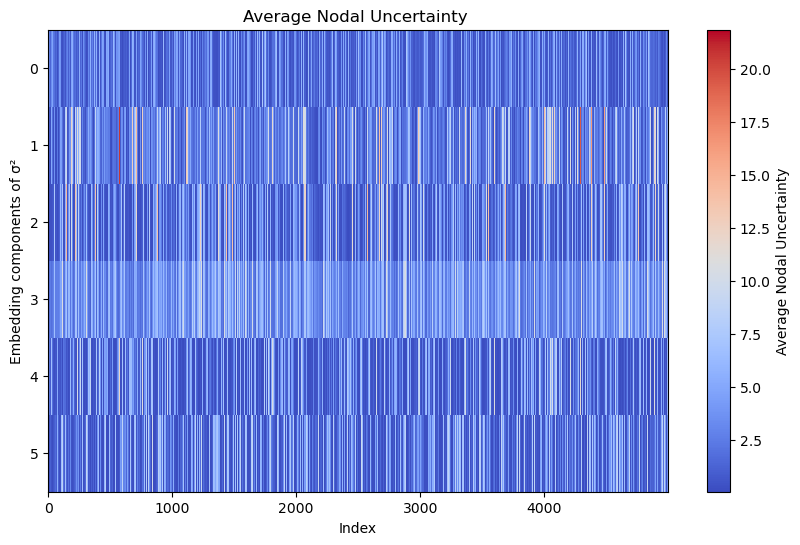

In [13]:
epochs = 200
nsamples = 5
learning_rate = 1e-3
seed = 0
z = color_label
A, Input_matrix = A, 'Adjacency'  ##连接矩阵
for K in [3]:

    if K == 2:###是否过拟合
        epochs = 600
    else:
        epochs = 200

    print('处理图数据')
    # A_train,X_train,z_train = A,X,z
    X = X.astype(np.float32)
    train_data = AttributedGraph(A, X, z, K, directed=True, Input_matrix=Input_matrix) ###

    for L in [6]:
        encoder = Encoder(X.shape[1], L)

        #learning_rate=0
        optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)

        iterations = epochs #// n_workers
        dataset = GraphDataset(train_data, nsamples, iterations)
        loader = DataLoader(
            dataset,
            batch_size=1,
        #     num_workers=n_workers,
            worker_init_fn=reset_seeds,
            collate_fn=lambda args: args,
        )

        #LAMBDA = 1e-6
        for batch_idx, data in enumerate(loader):
            encoder.train()
            optimizer.zero_grad()
            loss = encoder.compute_loss(data[0][0],data[0][1],data[0][2],data[0][3],data[0][4],data[0][5])
            
            #print(batch_idx,mu,sigma)
            #loss = BPR_loss(mu,sigma,LAMBDA)
            #print(data[0][0],data[0][1],data[0][2],data[0][3],data[0][4],data[0][5])
            if batch_idx% 10 == 0:
                mu,sigma = encoder(torch.tensor(data[0][0]))
                print(batch_idx,loss,torch.mean(sigma**2,axis=0))
            loss.backward()
            optimizer.step()

            
        # Create the heatmap
        sigma = sigma.detach().numpy()
        plt.figure(figsize=(10, 6))
        heatmap = plt.imshow(sigma.T**(2), aspect='auto', cmap='coolwarm', interpolation='nearest')

        # Add colorbar
        cbar = plt.colorbar(heatmap)
        cbar.set_label('Average Nodal Uncertainty')

        # Set labels
        plt.title('Average Nodal Uncertainty ')
        plt.xlabel('Index')
        plt.ylabel('Embedding components of σ²')

        # # Set x-ticks and y-ticks
        # plt.xticks(ticks=np.arange(30), labels=np.arange(7, 259, 7)[:30])
        # plt.yticks(ticks=np.arange(15), labels=np.arange(0, 30, 2))

        # Show the plot
        plt.show()

        torch.save(encoder,result_path+f'encoder{K}_{L}.pt')

        mu, sigma = encoder(torch.tensor(X))
        mu_learned = mu.detach().numpy()
        sigma_learned = sigma.detach().numpy()

        diag_elements = np.concatenate([1 / sigma_learned ** 2, 2 / sigma_learned ** 2], axis=-1)
        Fisher_g = np.zeros((X.shape[0], 2 * L, 2 * L))
        for i in range(X.shape[0]):
            np.fill_diagonal(Fisher_g[i], diag_elements[i])
        np.save(result_path+'Fisher_g',Fisher_g)

        Eigenvalue,sorted_Eigenvalue,relative_Eigenvalue = EigenIF(Fisher_g)

        #三种特征值图
        max1,max2 = np.argsort(np.mean(sigma_learned**2,axis=0))[-2:]
        X_plt,Y_plt = mu_learned[:,max1],mu_learned[:,max2]


In [14]:
print('k_nei', n_samples**(1/2),n_samples**(1/3),n_samples**(1/4))

k_nei 70.71067811865476 17.09975946676697 8.408964152537145


In [16]:
print(color_label)

[4140. 1613. 4576. ... 4077. 4272. 1488.]


In [17]:
from scipy.special import erf
def W1_distance(mu1, sigma1, mu2, sigma2):
    """Compute the 1-Wasserstein distance between two Gaussian distributions.
    Args:
        mu1: Mean of the first Gaussian (numpy array).
        sigma1: Covariance matrix of the first Gaussian (numpy array).
        mu2: Mean of the second Gaussian (numpy array).
        sigma2: Covariance matrix of the second Gaussian (numpy array)."""
    mu = np.abs(mu1 - mu2)
    sigma = np.abs(sigma1 - sigma2)
    Wass_dis = sigma * np.sqrt(2/np.pi) * np.exp(-mu**2/(2*sigma**2)) + \
           mu * erf(mu/(np.sqrt(2)*sigma))
    return np.sum(Wass_dis)


In [18]:

cRc_arr=[]
cRc_arr_eu=[]
cRc_arr_eu1=[]
for inds in np.split(A.indices, A.indptr)[1:-1]:
    self_ind=inds[0]
    cRc=0
    cRc_eu=0
    cRc_eu1=0
    for nei_k in range(1,len(inds)):
        dEu=np.linalg.norm(X[self_ind,:]-X[inds[nei_k],:])
        dEu1 = np.linalg.norm(X[self_ind,:]-X[inds[nei_k],:],ord=1)
        dWa1 = W1_distance(mu_learned[self_ind,:],sigma_learned[self_ind,:],\
                        mu_learned[inds[nei_k],:],sigma_learned[inds[nei_k],:])
        dFi=Fisher_dist(mu_learned[self_ind,:],sigma_learned[self_ind,:],\
                        mu_learned[inds[nei_k],:],sigma_learned[inds[nei_k],:])
        dWa=wasserstein_distance(mu_learned[self_ind,:],sigma_learned[self_ind,:],\
                        mu_learned[inds[nei_k],:],sigma_learned[inds[nei_k],:])
        cRc+=1-dWa/dFi
        cRc_eu+=1-dWa/dEu
        cRc_eu1+=1-dWa1/dEu1
    
    cRc_arr.append(cRc/len(inds))
    cRc_arr_eu.append(cRc_eu/len(inds))
    cRc_arr_eu1.append(cRc_eu1/len(inds))

crc = np.array(cRc_arr)
crc_eu = np.array(cRc_arr_eu)
crc_smooth = smooth_func(crc_eu)
crc_eu1 = np.array(cRc_arr_eu1)
crc_smooth1 = smooth_func(crc_eu1)

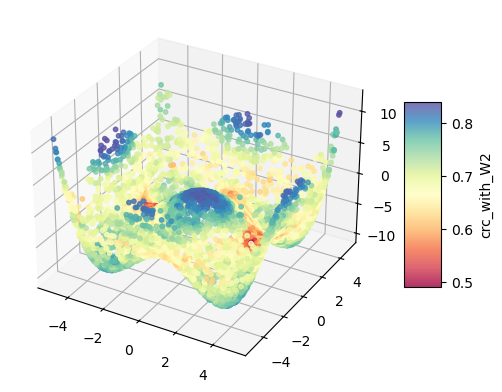

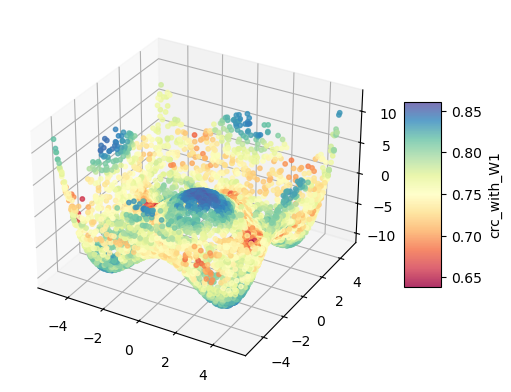

In [20]:
###cl ON ORIGINAL
# plot3d(x1,x2,x3,color=crc_smooth_w1,color_bar_name='color_bar',save_name=f'{subfolder}_{K}_{L}.png')

plot3d(x1,x2,x3,color=crc_smooth,color_bar_name='crc_with_W2',save_name=f'{subfolder}_{K}_{L}_W2.png')

plot3d(x1,x2,x3,color=crc_smooth1,color_bar_name='crc_with_W1',save_name=f'{subfolder}_{K}_{L}_W1.png')

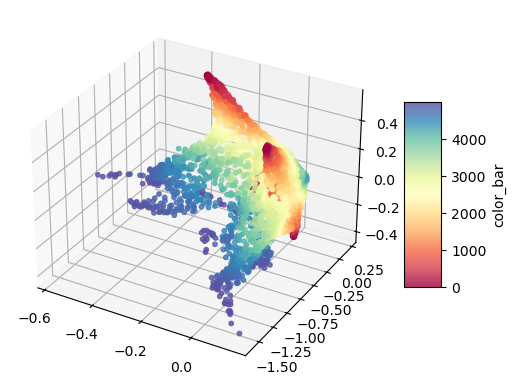

In [21]:
###CRC ON EMBEDDIGN
if L>2:
    max1,max2,max3 = np.argsort(np.mean(sigma_learned**2,axis=0))[-3:]
    plot3d(mu_learned[:,max1], mu_learned[:,max2], mu_learned[:,max3],
       color=color_label,color_bar_name='color_bar',save_name=f'cl on embedding{K}_{L}.png')

In [ ]:
len(color_label)

5000